<a href="https://colab.research.google.com/github/mustafizur41/30-Days-of-Geospatial-Analysis-with-Python/blob/main/Days_1_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install & Import Required Libraries

import sys
if 'osmnx' not in sys.modules:
    !pip install osmnx
if 'geopandas' not in sys.modules:
    !pip install geopandas
if 'folium' not in sys.modules:
    !pip install folium
import osmnx as ox
import geopandas as gpd
import folium

print(ox.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.2 MB/s eta 0:00:00
2.1.0


<Axes: >

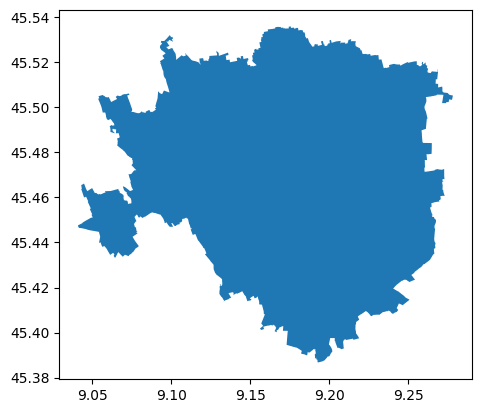

In [ ]:
# 2. Define Study Area
city_name = "Milan"
admin = ox.geocode_to_gdf(city_name)
admin.plot()

In [ ]:
# 3. Download OpenStreetMap Features
restaurants = ox.features_from_place(city_name, {"amenity": "restaurant"})
fuel_stations = ox.features_from_place(city_name, {"amenity": "fuel"})
healthcare = ox.features_from_place( city_name, {"amenity": ["hospital", "clinic", "doctors", "pharmacy"]})


print("Restaurants:", len(restaurants),"| Fuel Stations:", len(fuel_stations),"| Healthcare:", len(healthcare))

Restaurants: 2888 | Fuel Stations: 237 | Healthcare: 636


In [ ]:
# 4. Convert Polygon Features to Points
def to_points(gdf):
    if gdf.empty:
        return gdf
    return (gdf.to_crs(3857).centroid.to_crs(4326).to_frame("geometry") )

restaurants = to_points(restaurants)
fuel_stations = to_points(fuel_stations)
healthcare = to_points(healthcare)

In [ ]:
# 5. Calculate Map Extent

# Get the bounding box of the administrative boundary
minx, miny, maxx, maxy = admin.total_bounds
# Define map bounds for fitting
fit_bounds = [[miny, minx], [maxy, maxx]]
# Calculate the center of the map
center = [(miny + maxy) / 2, (minx + maxx) / 2]

In [ ]:
# 6. Create Base Map
m = folium.Map(
    location=center,
    zoom_start=10,
    tiles="CartoDB dark_matter",
    control_scale=True
)

# 7. Create Map Layers
admin_layer = folium.FeatureGroup( name="Admin Boundary", show=True)

# 8. Add Administrative Boundary
folium.GeoJson(
    admin,
    style_function=lambda feature: {
        "fillColor": "#ffffff",
        "color": "#ffffff",
        "weight": 2.5,
        "fillOpacity": 0.10
    }
).add_to(admin_layer)

admin_layer.add_to(m)

folium.LayerControl(collapsed=False, position="topright").add_to(m)

m.fit_bounds(fit_bounds)

m

In [ ]:
m = folium.Map(
    location=center,
    tiles="CartoDB dark_matter",
    control_scale=True
)

admin_layer = folium.FeatureGroup(
    name="Admin Boundary",
    show=True
)

restaurants_layer = folium.FeatureGroup(name="restaurants", show=True)
fuel_stations_layer = folium.FeatureGroup(name="fuel_stations", show=True)
health_layer = folium.FeatureGroup(name="Healthcare", show=True)

# Add the administrative boundary
folium.GeoJson(
    admin,
    style_function=lambda feature: {
        "fillColor": "#ffffff",
        "color": "#ffffff",
        "weight": 2.5,
        "fillOpacity": 0.15
    }
).add_to(admin_layer)

# 9. Function to Add Point Features
def add_points(gdf, feature_group, color):
    if gdf is not None and not gdf.empty:
        for _, row in gdf.iterrows():
            geom = row.geometry
            if geom is None:
                continue

            lat, lon = geom.y, geom.x

            folium.CircleMarker(
                location=[lat, lon],
                radius=2,
                weight=0.5,
                fill=True,
                fill_opacity=0.8,
                color=color,
                fill_color=color,
                # tooltip removed as requested
            ).add_to(feature_group)

admin_layer.add_to(m)

# 10. Add OpenStreetMap Features
add_points(restaurants, restaurants_layer, "#ff9933")
add_points(fuel_stations, fuel_stations_layer, "#44e0ff")
add_points(healthcare, health_layer, "#ff4444")

# 11. Add Layer Control
admin_layer.add_to(m)
restaurants_layer.add_to(m)
fuel_stations_layer.add_to(m)
health_layer.add_to(m)

folium.LayerControl(collapsed=False, position="topright").add_to(m)

m.fit_bounds(fit_bounds)
m.save("milan.html")
m